# Quick Start

This tutorial will show you the minimal steps to simulate a stellar light curve with a single active region using SAJAX.

# Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import jax
import jax.numpy as jnp
from sajax import compute_light_curve

# Set random seed for reproducibility
np.random.seed(42)

print("JAX version:", jax.__version__)
print("Available devices:", jax.devices())

JAX version: 0.9.1
Available devices: [CpuDevice(id=0)]


# Load Data from Files

In [ ]:
# Load spectra (wavelength, flux_quiet, flux_active)
spectra_data = np.loadtxt('./_static/input_spectrum.txt', skiprows=1)  # Adjust path as needed
wavelength = spectra_data[:, 0]
flux_quiet = spectra_data[:, 1]
flux_active = spectra_data[:, 2]

# Load wavelength-dependent limb-darkening coefficients
ld_data = np.loadtxt('./_static/ldc.txt', skiprows=1)  # Adjust path as needed
u1_wavelength = ld_data[:, 0]
u2_wavelength = ld_data[:, 1]

# Verify data alignment
print("=" * 60)
print("DATA SUMMARY")
print("=" * 60)
print(f"Wavelength range:     {wavelength.min():.3f} - {wavelength.max():.3f} μm")
print(f"N wavelengths:        {len(wavelength)}")
print(f"Flux quiet range:     {flux_quiet.min():.4f} - {flux_quiet.max():.4f}")
print(f"Flux active range:    {flux_active.min():.4f} - {flux_active.max():.4f}")
print(f"LD u1 range:          {u1_wavelength.min():.3f} - {u1_wavelength.max():.3f}")
print(f"LD u2 range:          {u2_wavelength.min():.3f} - {u2_wavelength.max():.3f}")
print("=" * 60)

DATA SUMMARY
Wavelength range:     3010.000 - 9980.000 μm
N wavelengths:        698
Flux quiet range:     0.0115 - 1.0000
Flux active range:    0.0006 - 0.2926
LD u1 range:          0.368 - 1.721
LD u2 range:          -0.785 - 0.198


# Visualize Input Spectra and LD Coefficients

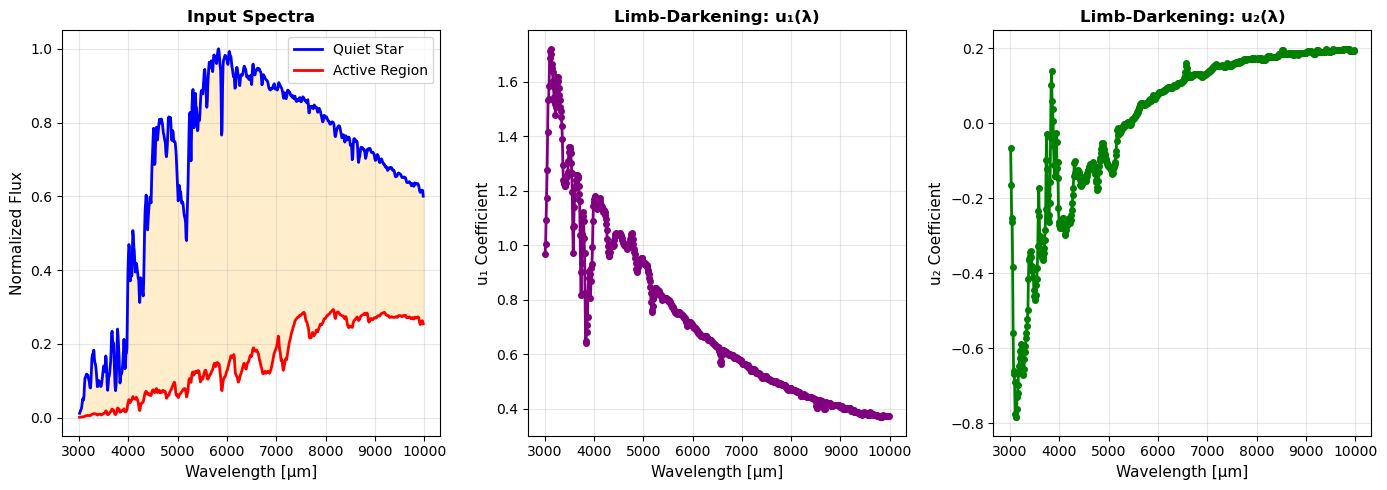


Mean spectral contrast (active region):  77.0%


In [3]:
fig = plt.figure(figsize=(14, 5))
gs = GridSpec(1, 3, figure=fig)

# Plot 1: Spectra
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(wavelength, flux_quiet, 'b-', linewidth=2, label='Quiet Star')
ax1.plot(wavelength, flux_active, 'r-', linewidth=2, label='Active Region')
ax1.fill_between(wavelength, flux_quiet, flux_active, alpha=0.2, color='orange')
ax1.set_xlabel('Wavelength [μm]', fontsize=11)
ax1.set_ylabel('Normalized Flux', fontsize=11)
ax1.set_title('Input Spectra', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: LD u1 coefficient
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(wavelength, u1_wavelength, 'o-', linewidth=2, color='purple', markersize=4)
ax2.set_xlabel('Wavelength [μm]', fontsize=11)
ax2.set_ylabel('u₁ Coefficient', fontsize=11)
ax2.set_title('Limb-Darkening: u₁(λ)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Plot 3: LD u2 coefficient
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(wavelength, u2_wavelength, 'o-', linewidth=2, color='green', markersize=4)
ax3.set_xlabel('Wavelength [μm]', fontsize=11)
ax3.set_ylabel('u₂ Coefficient', fontsize=11)
ax3.set_title('Limb-Darkening: u₂(λ)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print spectrum contrast
contrast = (np.mean(flux_quiet) - np.mean(flux_active)) / np.mean(flux_quiet)
print(f"\nMean spectral contrast (active region):  {contrast*100:.1f}%")

# Case 1 - Single Spot, Basic Configuration


CASE 1: Single Spot - Basic Configuration
build_model: scalar LDCs provided for 'quadratic' law ([0.7184, 0.0164]) — broadcasting across all 698 wavelength bins.


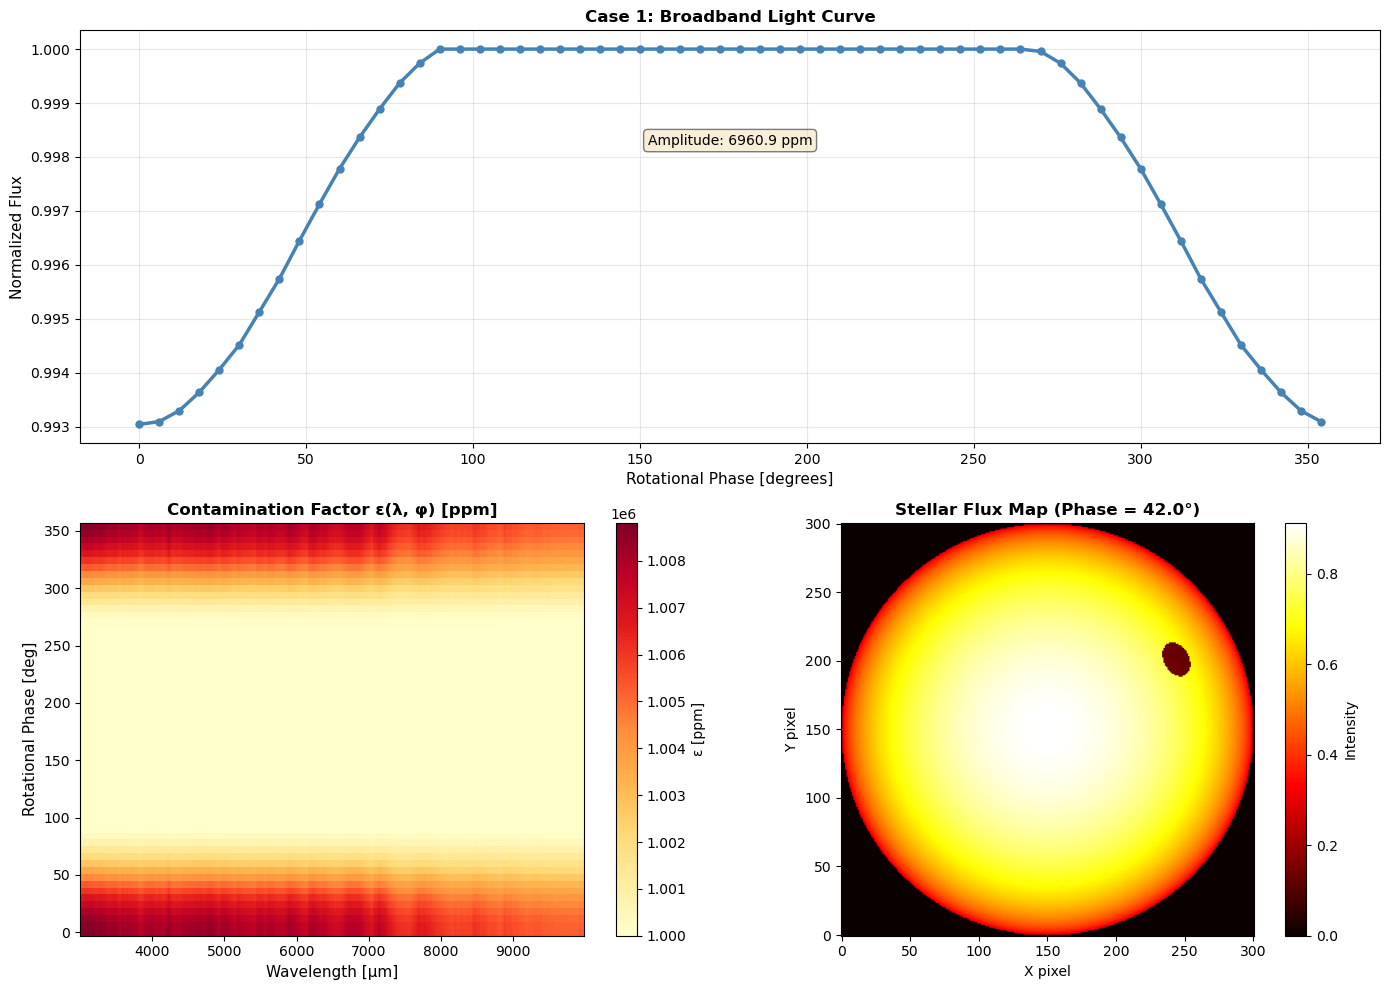


Results:
  Broadband LC amplitude:  6960.87 ppm
  Max contamination:       1008814.00 ppm
  Epsilon shape:           (60, 698) (phases x wavelengths)


In [ ]:
print("\n" + "="*60)
print("CASE 1: Single Spot - Basic Configuration")
print("="*60)

# Use mean LD coefficients
u1_mean = np.mean(u1_wavelength)
u2_mean = np.mean(u2_wavelength)

params_case1 = dict(
    u1              = u1_mean,
    u2              = u2_mean,
    inc_star        = 90.0,          # Equator-on view
)

result_case1 = compute_light_curve(
    wavelength          = wavelength,
    flux_quiet          = flux_quiet,
    flux_active         = flux_active,
    params              = params_case1,
    ar_lat              = [20.0],                    # Single spot at 20° lat
    ar_long             = [0.0],
    ar_size             = [5.0],                     # 5° radius
    phases_rot          = np.linspace(0, 360, 60, endpoint=False),
    stellar_grid_size   = 100,                       # stellar radius in pixels
    ve                  = 2.0,                       # Equatorial velocity [km/s]
    ldc_mode            = "quadratic",
    plot_map_wavelength = np.mean(wavelength),
)

phases = np.linspace(0, 360, 60, endpoint=False)

# Plot light curves
fig, axes = plt.subplot_mosaic([['A', 'A'], ['B', 'C']], figsize=(14, 10))

# Plot 1: Broadband light curve
ax = axes['A']
ax.plot(phases, result_case1["lc"], 'o-', linewidth=2.5, markersize=5, color='steelblue')
ax.set_xlabel('Rotational Phase [degrees]', fontsize=11)
ax.set_ylabel('Normalized Flux', fontsize=11)
ax.set_title('Case 1: Broadband Light Curve', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
lc_amplitude = np.max(result_case1["lc"]) - np.min(result_case1["lc"])
ax.text(0.5, 0.75, f'Amplitude: {lc_amplitude*1e6:.1f} ppm', 
        transform=ax.transAxes, ha='center', va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Contamination factor heatmap
ax = axes['B']
epsilon = result_case1["epsilon"]
im = ax.pcolormesh(wavelength, phases, epsilon*1e6, shading='auto', cmap='YlOrRd')
ax.set_xlabel('Wavelength [μm]', fontsize=11)
ax.set_ylabel('Rotational Phase [deg]', fontsize=11)
ax.set_title('Contamination Factor ε(λ, φ) [ppm]', fontsize=12, fontweight='bold')
cbar = plt.colorbar(im, ax=ax, label='ε [ppm]')

# Plot 4: Stellar map visualization
ax = axes['C']
phase_idx = np.argmin(np.abs(phases - 45))  # Find phase closest to 45°
star_maps = result_case1["star_maps"]
map_data = star_maps[phase_idx]
im = ax.imshow(map_data, cmap='hot', origin='lower')
ax.set_title(f'Stellar Flux Map (Phase = {phases[phase_idx]:.1f}°)', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('X pixel', fontsize=10)
ax.set_ylabel('Y pixel', fontsize=10)
plt.colorbar(im, ax=ax, label='Intensity')

plt.tight_layout()
plt.show()

print(f"\nResults:")
print(f"  Broadband LC amplitude:  {lc_amplitude*1e6:.2f} ppm")
print(f"  Max contamination:       {np.max(epsilon)*1e6:.2f} ppm")
print(f"  Epsilon shape:           {epsilon.shape} (phases x wavelengths)")

# Case 2 - Multiple Spots at Different Latitudes


CASE 2: Multiple Spots
build_model: scalar LDCs provided for 'quadratic' law ([0.7184, 0.0164]) — broadcasting across all 698 wavelength bins.


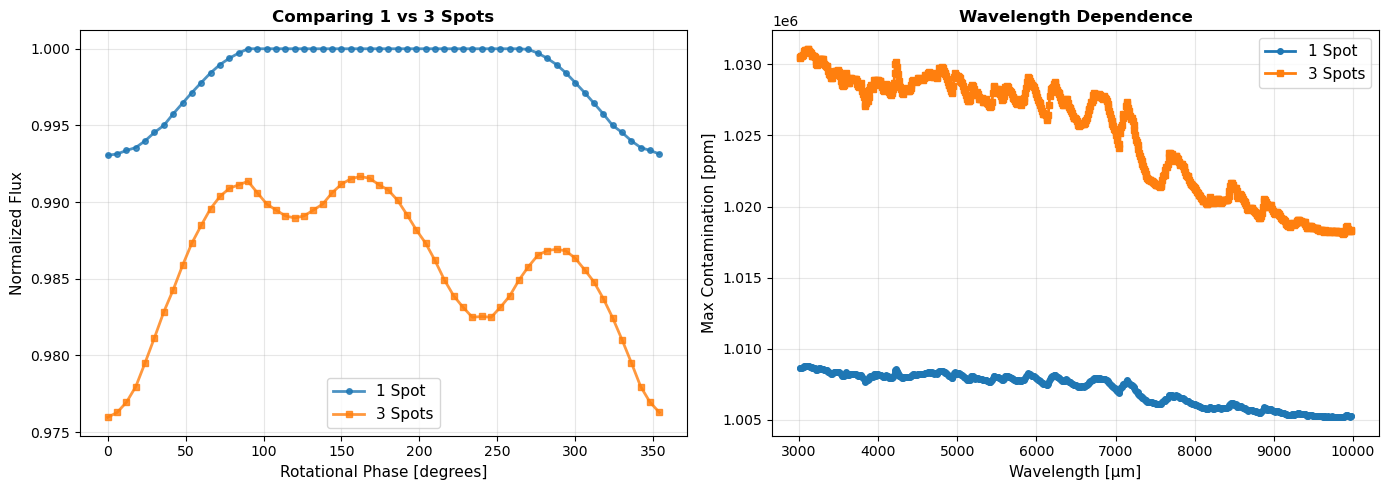


Results:
  1 Spot amplitude:        6949.60 ppm
  3 Spots amplitude:       15706.12 ppm
  Amplitude increase:      126.0%


In [5]:
print("\n" + "="*60)
print("CASE 2: Multiple Spots")
print("="*60)

result_case2 = compute_light_curve(
    wavelength          = wavelength,
    flux_quiet          = flux_quiet,
    flux_active         = flux_active,
    params              = params_case1,
    ar_lat              = [30.0, -20.0, 5.0],        # Three spots
    ar_long             = [0.0, 120.0, 240.0],
    ar_size             = [10.0, 8.0, 6.0],                     
    phases_rot          = np.linspace(0, 360, 60, endpoint=False),
    stellar_grid_size   = 100,      # stellar radius in pixels
    ve                  = 2.0,
    ldc_mode            = "quadratic",
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Compare single vs multiple spots
ax = axes[0]
ax.plot(phases, result_case1["lc"], 'o-', label='1 Spot', linewidth=2, markersize=4, alpha=0.8)
ax.plot(phases, result_case2["lc"], 's-', label='3 Spots', linewidth=2, markersize=4, alpha=0.8)
ax.set_xlabel('Rotational Phase [degrees]', fontsize=11)
ax.set_ylabel('Normalized Flux', fontsize=11)
ax.set_title('Comparing 1 vs 3 Spots', fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Multiple spots: max contamination per wavelength
ax = axes[1]
epsilon1 = result_case1["epsilon"]
epsilon2 = result_case2["epsilon"]
max_cont1 = np.max(epsilon1, axis=0) * 1e6
max_cont2 = np.max(epsilon2, axis=0) * 1e6
ax.plot(wavelength, max_cont1, 'o-', label='1 Spot', linewidth=2, markersize=4)
ax.plot(wavelength, max_cont2, 's-', label='3 Spots', linewidth=2, markersize=4)
ax.set_xlabel('Wavelength [μm]', fontsize=11)
ax.set_ylabel('Max Contamination [ppm]', fontsize=11)
ax.set_title('Wavelength Dependence', fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

lc_amp_2 = np.max(result_case2["lc"]) - np.min(result_case2["lc"])
print(f"\nResults:")
print(f"  1 Spot amplitude:        {lc_amplitude*1e6:.2f} ppm")
print(f"  3 Spots amplitude:       {lc_amp_2*1e6:.2f} ppm")
print(f"  Amplitude increase:      {(lc_amp_2 - lc_amplitude)/lc_amplitude * 100:.1f}%")

# Case 3 - Different Stellar Inclinations


CASE 3: Effect of Stellar Inclination
build_model: scalar LDCs provided for 'quadratic' law ([0.7184, 0.0164]) — broadcasting across all 698 wavelength bins.
build_model: scalar LDCs provided for 'quadratic' law ([0.7184, 0.0164]) — broadcasting across all 698 wavelength bins.
build_model: scalar LDCs provided for 'quadratic' law ([0.7184, 0.0164]) — broadcasting across all 698 wavelength bins.


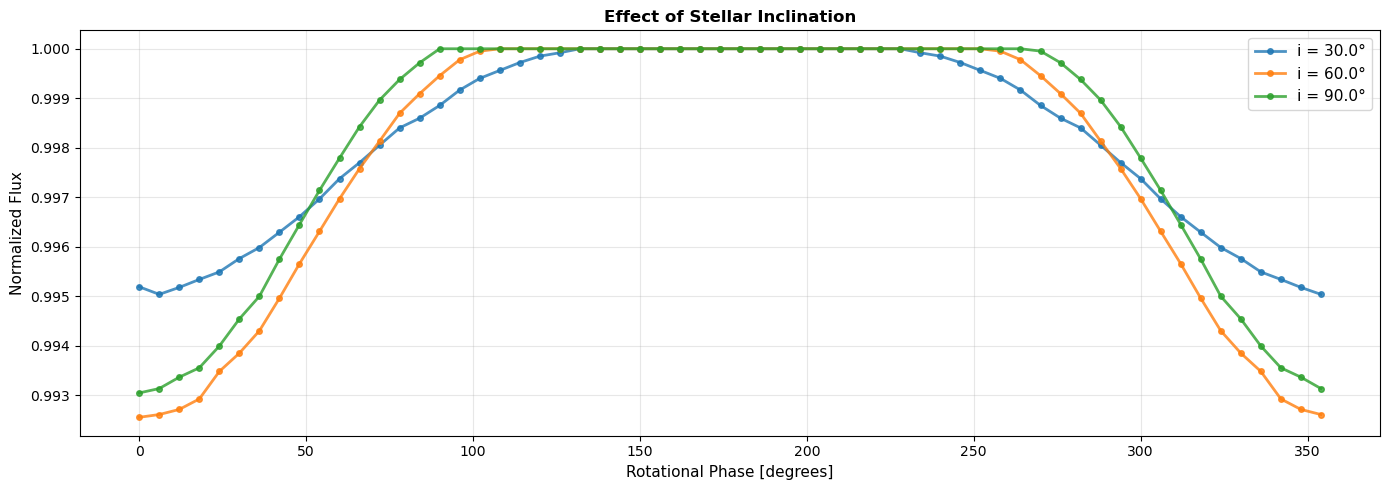


Amplitudes vs Inclination:
  i =  30.0°:  4959.29 ppm
  i =  60.0°:  7441.94 ppm
  i =  90.0°:  6949.60 ppm


In [6]:
print("\n" + "="*60)
print("CASE 3: Effect of Stellar Inclination")
print("="*60)

inclinations = [30.0, 60.0, 90.0]  # pole-on to equator-on
results_inc = []

for inc in inclinations:
    params_inc = dict(u1=u1_mean, u2=u2_mean, inc_star=inc)
    result = compute_light_curve(
        wavelength          = wavelength,
        flux_quiet          = flux_quiet,
        flux_active         = flux_active,
        params              = params_inc,
        ar_lat              = [20.0],
        ar_long             = [0.0],
        ar_size             = [5.0],                     # 5° radius
        phases_rot          = np.linspace(0, 360, 60, endpoint=False),
        stellar_grid_size   = 100,      # stellar radius in pixels
        ve                  = 2.0,
        ldc_mode            = "quadratic",
    )
    results_inc.append(result)

fig, ax = plt.subplots(1, 1, figsize=(14, 5))

# Plot: LC vs inclination
for i, inc in enumerate(inclinations):
    ax.plot(phases, results_inc[i]["lc"], 'o-', label=f'i = {inc}°', 
            linewidth=2, markersize=4, alpha=0.8)
ax.set_xlabel('Rotational Phase [degrees]', fontsize=11)
ax.set_ylabel('Normalized Flux', fontsize=11)
ax.set_title('Effect of Stellar Inclination', fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAmplitudes vs Inclination:")
amplitudes = [np.max(r["lc"]) - np.min(r["lc"]) for r in results_inc]

for inc, amp in zip(inclinations, amplitudes):
    print(f"  i = {inc:5.1f}°:  {amp*1e6:6.2f} ppm")

# Case 4 - Wavelength-Dependent Limb-Darkening


CASE 4: Wavelength-Dependent LD Coefficients
build_model: per-wavelength LDCs provided for 'quadratic' law (2 coefficient(s), 698 wavelength bins).


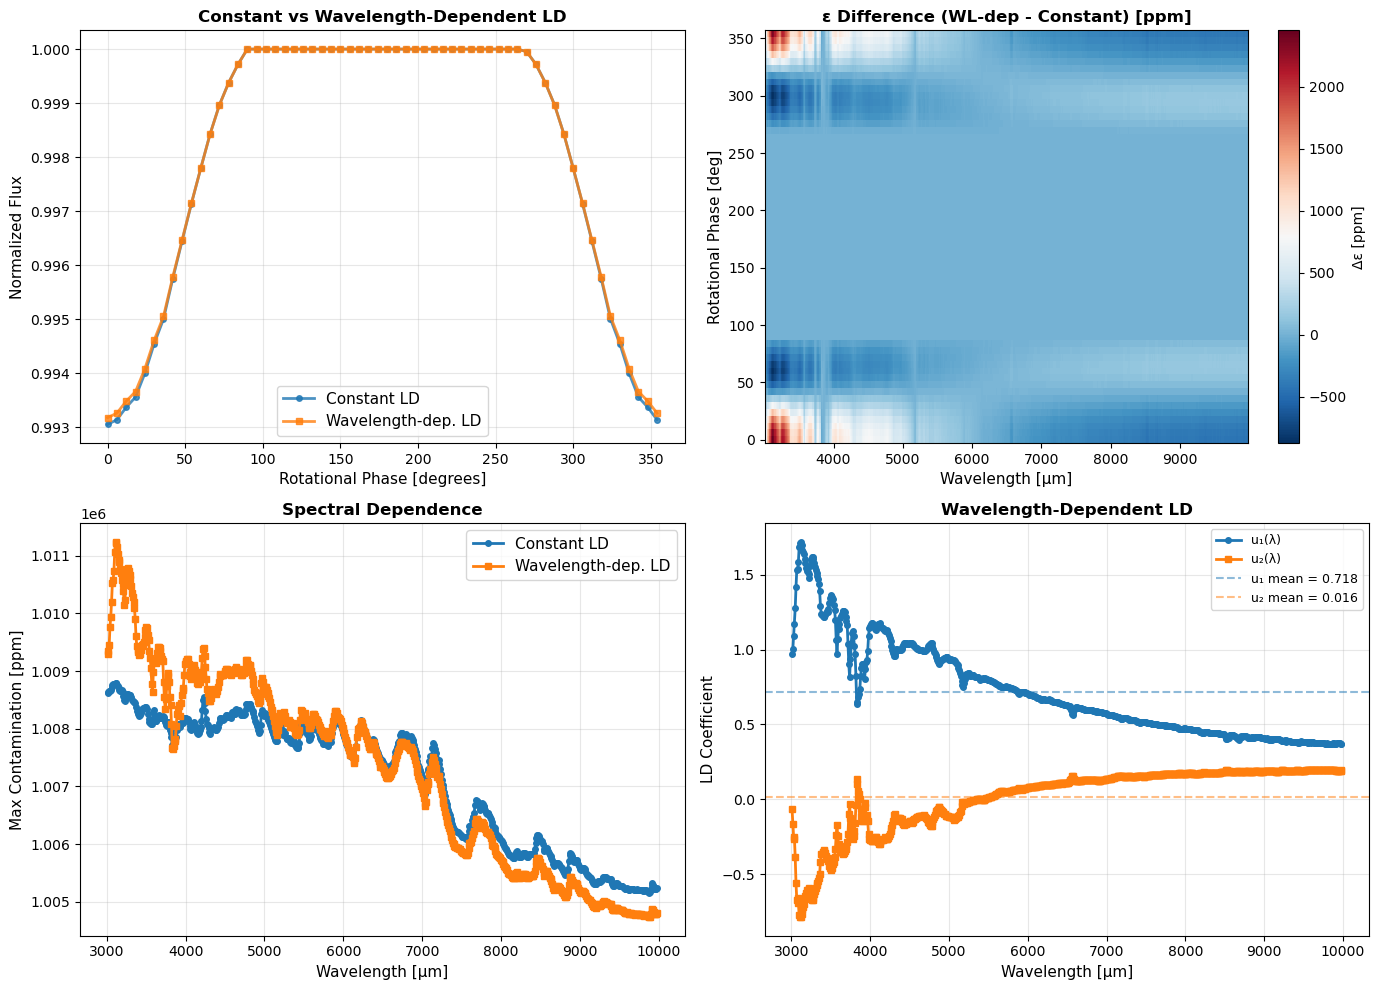


Results:
  Constant LD light-curve amplitude:        6949.60 ppm
  Wavelength-dep. LD light-curve amplitude: 6824.73 ppm


In [7]:
print("\n" + "="*60)
print("CASE 4: Wavelength-Dependent LD Coefficients")
print("="*60)

result_case4 = compute_light_curve(
    wavelength          = wavelength,
    flux_quiet          = flux_quiet,
    flux_active         = flux_active,
    params              = dict(u1=u1_wavelength, u2=u2_wavelength, inc_star=90.0),
    ar_lat              = [20.0],
    ar_long             = [0.0],
    ar_size             = [5.0],                     # 5° radius
    phases_rot          = np.linspace(0, 360, 60, endpoint=False),
    stellar_grid_size   = 100,      # stellar radius in pixels
    ve                  = 2.0,
    ldc_mode            = "quadratic",
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Compare constant vs wavelength-dependent LD
ax = axes[0, 0]
ax.plot(phases, result_case1["lc"], 'o-', label='Constant LD', 
        linewidth=2, markersize=4, alpha=0.8)
ax.plot(phases, result_case4["lc"], 's-', label='Wavelength-dep. LD', 
        linewidth=2, markersize=4, alpha=0.8)
ax.set_xlabel('Rotational Phase [degrees]', fontsize=11)
ax.set_ylabel('Normalized Flux', fontsize=11)
ax.set_title('Constant vs Wavelength-Dependent LD', fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Plot 2: Contamination difference
ax = axes[0, 1]
eps_diff = (result_case4["epsilon"] - result_case1["epsilon"]) * 1e6
im = ax.pcolormesh(wavelength, phases, eps_diff, shading='auto', cmap='RdBu_r')
ax.set_xlabel('Wavelength [μm]', fontsize=11)
ax.set_ylabel('Rotational Phase [deg]', fontsize=11)
ax.set_title('ε Difference (WL-dep - Constant) [ppm]', fontsize=12, fontweight='bold')
cbar = plt.colorbar(im, ax=ax, label='Δε [ppm]')

# Plot 3: Maximum contamination per wavelength
ax = axes[1, 0]
max_cont_const = np.max(result_case1["epsilon"], axis=0) * 1e6
max_cont_wldep = np.max(result_case4["epsilon"], axis=0) * 1e6
ax.plot(wavelength, max_cont_const, 'o-', label='Constant LD', linewidth=2, markersize=4)
ax.plot(wavelength, max_cont_wldep, 's-', label='Wavelength-dep. LD', linewidth=2, markersize=4)
ax.set_xlabel('Wavelength [μm]', fontsize=11)
ax.set_ylabel('Max Contamination [ppm]', fontsize=11)
ax.set_title('Spectral Dependence', fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Plot 4: LD variation
ax = axes[1, 1]
ax.plot(wavelength, u1_wavelength, 'o-', label='u₁(λ)', linewidth=2, markersize=4)
ax.plot(wavelength, u2_wavelength, 's-', label='u₂(λ)', linewidth=2, markersize=4)
ax.axhline(u1_mean, color='C0', linestyle='--', alpha=0.5, label=f'u₁ mean = {u1_mean:.3f}')
ax.axhline(u2_mean, color='C1', linestyle='--', alpha=0.5, label=f'u₂ mean = {u2_mean:.3f}')
ax.set_xlabel('Wavelength [μm]', fontsize=11)
ax.set_ylabel('LD Coefficient', fontsize=11)
ax.set_title('Wavelength-Dependent LD', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nResults:")
print(f"  Constant LD light-curve amplitude:        {lc_amplitude*1e6:.2f} ppm")
print(f"  Wavelength-dep. LD light-curve amplitude: {(np.max(result_case4['lc']) - np.min(result_case4['lc']))*1e6:.2f} ppm")